In [1]:
from math import isqrt
from sklearn.inspection import DecisionBoundaryDisplay

from utils import *

current_dir = globals()['_dh'][0]

# Quadratic fields

In [2]:
df_quadratic = pl.read_csv(f"{current_dir}/data_nf/nf_2.csv")

In [3]:
df_stats(df_quadratic, label="rank")

Number of rows: 1371548
Number of columns: 1004
Head: shape: (5, 1_004)
┌─────────┬──────┬──────┬──────┬───┬─────────┬─────────┬─────────┬─────────┐
│ label   ┆ rank ┆ c_0  ┆ c_1  ┆ … ┆ a_00997 ┆ a_00998 ┆ a_00999 ┆ a_01000 │
│ ---     ┆ ---  ┆ ---  ┆ ---  ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str     ┆ i64  ┆ f64  ┆ f64  ┆   ┆ i64     ┆ i64     ┆ i64     ┆ i64     │
╞═════════╪══════╪══════╪══════╪═══╪═════════╪═════════╪═════════╪═════════╡
│ 2.0.3.1 ┆ 0    ┆ 1.0  ┆ -1.0 ┆ … ┆ 2       ┆ 0       ┆ 2       ┆ 0       │
│ 2.0.4.1 ┆ 0    ┆ 1.0  ┆ 0.0  ┆ … ┆ 2       ┆ 0       ┆ 0       ┆ 4       │
│ 2.2.5.1 ┆ 1    ┆ -1.0 ┆ -1.0 ┆ … ┆ 0       ┆ 0       ┆ 0       ┆ 0       │
│ 2.0.7.1 ┆ 0    ┆ 2.0  ┆ -1.0 ┆ … ┆ 0       ┆ 4       ┆ 0       ┆ 0       │
│ 2.0.8.1 ┆ 0    ┆ 2.0  ┆ 0.0  ┆ … ┆ 0       ┆ 2       ┆ 0       ┆ 0       │
└─────────┴──────┴──────┴──────┴───┴─────────┴─────────┴─────────┴─────────┘
Label: rank
Label value counts: shape: (2, 3)
┌──────┬────────┬─────────┐
│ rank 

Running experiment: quadratic_rank_dt_poly
Data: quadratic_rank_dt_poly, c
Train: (1097238, 2)
Test (rank): (274310, 2)
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    137648
           1     1.0000    1.0000    1.0000    136662

    accuracy                         1.0000    274310
   macro avg     1.0000    1.0000    1.0000    274310
weighted avg     1.0000    1.0000    1.0000    274310

Confusion matrix


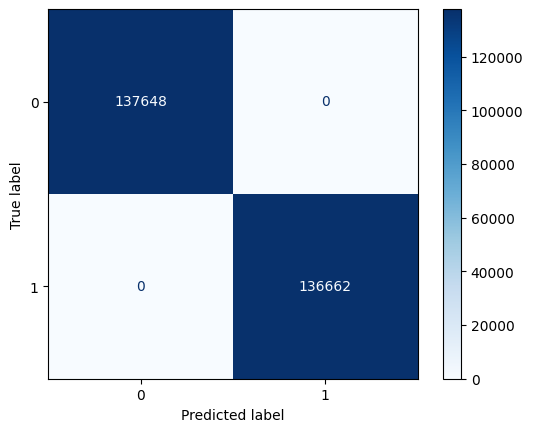

Running experiment: quadratic_rank_lr_poly
Data: quadratic_rank_lr_poly, c
Train: (1097238, 2)
Test (rank): (274310, 2)


/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    137648
           1     1.0000    1.0000    1.0000    136662

    accuracy                         1.0000    274310
   macro avg     1.0000    1.0000    1.0000    274310
weighted avg     1.0000    1.0000    1.0000    274310

Confusion matrix


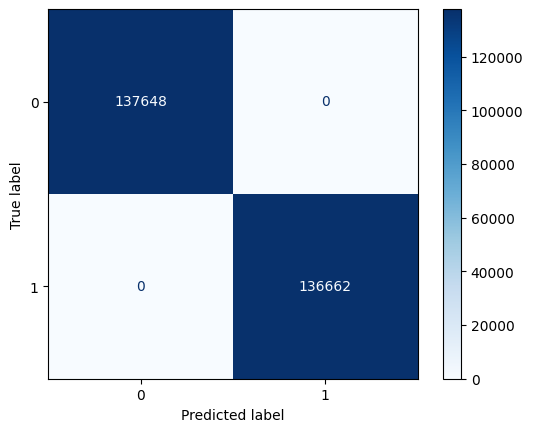

model weights: [[-0.14446824  0.00114197]]
model bias: [-0.00180144]
Running experiment: quadratic_rank_dt_zc_1000
Data: quadratic_rank_dt_zc_1000, a
Train: (1097238, 1000)
Test (rank): (274310, 1000)
              precision    recall  f1-score   support

           0     0.4915    0.4883    0.4899    137648
           1     0.4880    0.4912    0.4896    136662

    accuracy                         0.4898    274310
   macro avg     0.4898    0.4898    0.4898    274310
weighted avg     0.4898    0.4898    0.4898    274310

Confusion matrix


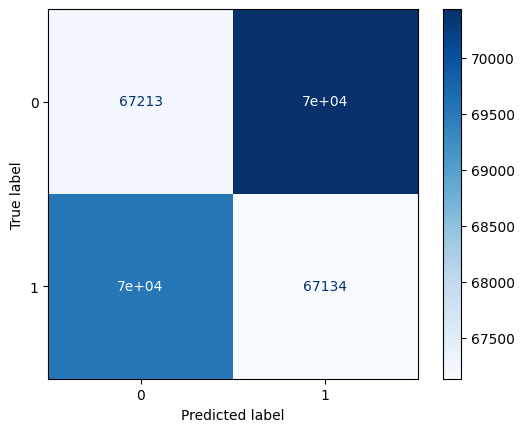

Running experiment: quadratic_rank_lr_zc_1000
Data: quadratic_rank_lr_zc_1000, a
Train: (1097238, 1000)
Test (rank): (274310, 1000)


/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0     0.4832    0.4542    0.4683    137648
           1     0.4816    0.5108    0.4958    136662

    accuracy                         0.4824    274310
   macro avg     0.4824    0.4825    0.4820    274310
weighted avg     0.4824    0.4824    0.4820    274310

Confusion matrix


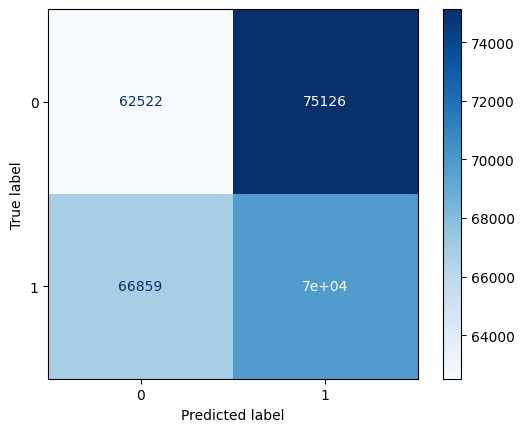

In [4]:
run_experiments(
    df_quadratic,
    "quadratic_rank",
    class_names=["0", "1"],
    current_dir=current_dir,
    save_tree_fig=False,
)

Experiment with synthetic quadratic field dataset, where 1000000 pairs of $c_0$ and $c_1$ are randomly sampled from $[-M, M]$ and $[-M^2 / 4, M^2 / 4]$ for $M = 5000$.

In [5]:
np.random.seed(42)

def data_custom(N=10 ** 6, M=10 ** 4):
    data = []
    is_sampled = {}
    while len(data) < N:
        c1 = np.random.randint(-M, M+1)
        c0 = np.random.randint(-M ** 2 // 4, M ** 2 // 4 + 1)
        d = c1 ** 2 - 4 * c0
        if d >= 0 and isqrt(d) ** 2 == d:
            continue
        r = 1 if d > 0 else 0
        if (c0, c1) not in is_sampled:
            data.append([c0, c1, r])
            is_sampled[(c0, c1)] = True

    df = pl.DataFrame(data, schema=["c_0", "c_1", "rank"])
    return df

In [6]:
df_custom = data_custom(N=1000000, M=5000)
df_stats(df_custom, label="rank")

Number of rows: 1000000
Number of columns: 3
Head: shape: (5, 3)
┌──────────┬───────┬──────┐
│ c_0      ┆ c_1   ┆ rank │
│ ---      ┆ ---   ┆ ---  │
│ i64      ┆ i64   ┆ i64  │
╞══════════╪═══════╪══════╡
│ 173388   ┆ 2270  ┆ 1    │
│ 300634   ┆ 390   ┆ 0    │
│ -1945428 ┆ 191   ┆ 1    │
│ -4015511 ┆ 734   ┆ 1    │
│ 3708614  ┆ -4534 ┆ 1    │
└──────────┴───────┴──────┘
Label: rank
Label value counts: shape: (2, 3)
┌──────┬────────┬──────────┐
│ rank ┆ len    ┆ percent  │
│ ---  ┆ ---    ┆ ---      │
│ i64  ┆ u32    ┆ f64      │
╞══════╪════════╪══════════╡
│ 0    ┆ 333374 ┆ 0.333374 │
│ 1    ┆ 666626 ┆ 0.666626 │
└──────┴────────┴──────────┘


/var/folders/7h/7r4qms6j40sc8f7hnfp0qg_80000gn/T/ipykernel_44265/1630524609.py:17: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df = pl.DataFrame(data, schema=["c_0", "c_1", "rank"])


Data: quadratic_rank_synthetic_dt, c
Train: (800000, 2)
Test (rank): (200000, 2)
              precision    recall  f1-score   support

           0     0.9987    0.9984    0.9985     66932
           1     0.9992    0.9993    0.9993    133068

    accuracy                         0.9990    200000
   macro avg     0.9989    0.9989    0.9989    200000
weighted avg     0.9990    0.9990    0.9990    200000

Confusion matrix


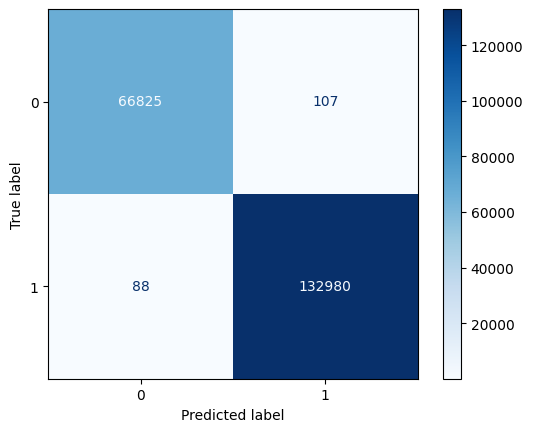

Data: quadratic_rank_synthetic_lr, c
Train: (800000, 2)
Test (rank): (200000, 2)


/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0     0.8090    0.8043    0.8067     66932
           1     0.9019    0.9045    0.9032    133068

    accuracy                         0.8710    200000
   macro avg     0.8554    0.8544    0.8549    200000
weighted avg     0.8708    0.8710    0.8709    200000

Confusion matrix


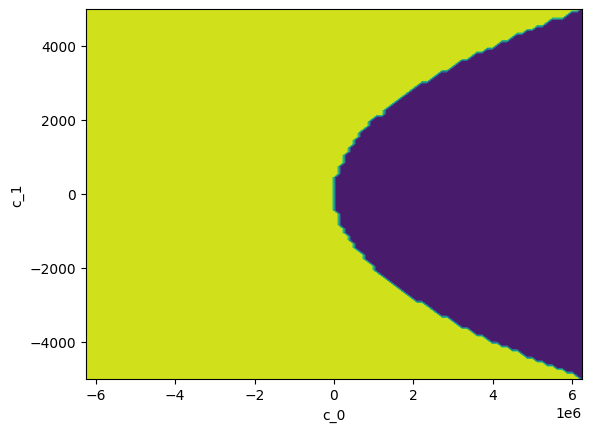

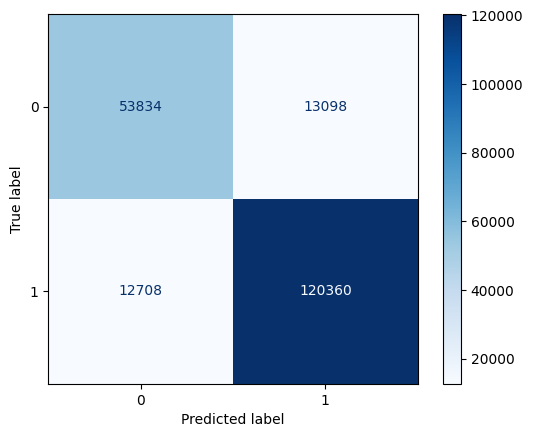

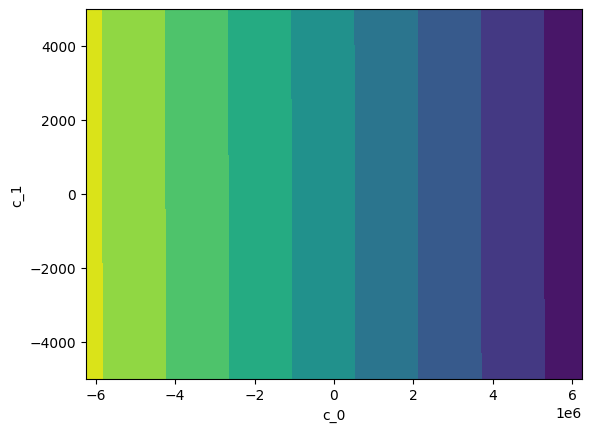

In [7]:
from sklearn.inspection import DecisionBoundaryDisplay


model_dt, acc = run_experiment(df_custom, "quadratic_rank_synthetic_dt", feature_type="c", model_type="dt")
X, y = X_y(df_custom, feature_type="c", N=1000000)
DecisionBoundaryDisplay.from_estimator(model_dt, X)
plt.savefig(f"{current_dir}/figs/dt/quadratic_rank_synthetic_dt.png")

model_lr, acc = run_experiment(df_custom, "quadratic_rank_synthetic_lr", feature_type="c", model_type="lr")
DecisionBoundaryDisplay.from_estimator(model_lr, X)
plt.savefig(f"{current_dir}/figs/lr/quadratic_rank_synthetic_lr.png")

# Cubic fields

In [8]:
df_cubic = pl.read_csv(f"{current_dir}/data_nf/nf_3.csv")

In [9]:
df_stats(df_cubic, label="rank")

Number of rows: 1179937
Number of columns: 1005
Head: shape: (5, 1_005)
┌──────────┬──────┬──────┬──────┬───┬─────────┬─────────┬─────────┬─────────┐
│ label    ┆ rank ┆ c_0  ┆ c_1  ┆ … ┆ a_00997 ┆ a_00998 ┆ a_00999 ┆ a_01000 │
│ ---      ┆ ---  ┆ ---  ┆ ---  ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str      ┆ i64  ┆ f64  ┆ f64  ┆   ┆ i64     ┆ i64     ┆ i64     ┆ i64     │
╞══════════╪══════╪══════╪══════╪═══╪═════════╪═════════╪═════════╪═════════╡
│ 3.1.23.1 ┆ 1    ┆ 1.0  ┆ 0.0  ┆ … ┆ 3       ┆ 0       ┆ 1       ┆ 2       │
│ 3.1.31.1 ┆ 1    ┆ -1.0 ┆ 1.0  ┆ … ┆ 0       ┆ 0       ┆ 2       ┆ 1       │
│ 3.1.44.1 ┆ 1    ┆ 1.0  ┆ 1.0  ┆ … ┆ 1       ┆ 3       ┆ 0       ┆ 1       │
│ 3.3.49.1 ┆ 2    ┆ 1.0  ┆ -2.0 ┆ … ┆ 0       ┆ 0       ┆ 0       ┆ 1       │
│ 3.1.59.1 ┆ 1    ┆ -1.0 ┆ 2.0  ┆ … ┆ 0       ┆ 0       ┆ 1       ┆ 2       │
└──────────┴──────┴──────┴──────┴───┴─────────┴─────────┴─────────┴─────────┘
Label: rank
Label value counts: shape: (2, 3)
┌──────┬────────┬───────

Running experiment: cubic_rank_dt_poly
Data: cubic_rank_dt_poly, c
Train: (943949, 3)
Test (rank): (235988, 3)
              precision    recall  f1-score   support

           1     0.9970    0.9970    0.9970    182393
           2     0.9899    0.9897    0.9898     53595

    accuracy                         0.9954    235988
   macro avg     0.9935    0.9934    0.9934    235988
weighted avg     0.9954    0.9954    0.9954    235988

Confusion matrix


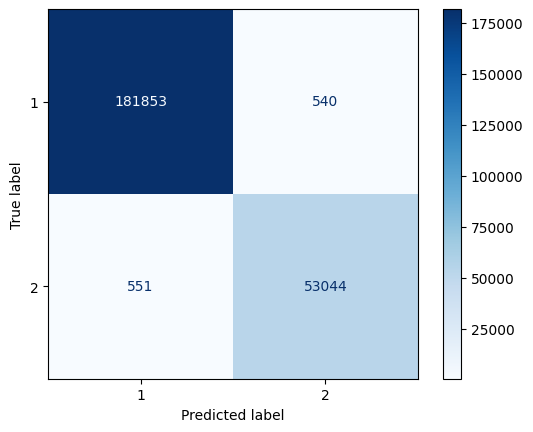

Running experiment: cubic_rank_lr_poly
Data: cubic_rank_lr_poly, c
Train: (943949, 3)
Test (rank): (235988, 3)


/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           1     0.7477    0.2512    0.3761    182393
           2     0.2183    0.7115    0.3341     53595

    accuracy                         0.3558    235988
   macro avg     0.4830    0.4814    0.3551    235988
weighted avg     0.6275    0.3558    0.3665    235988

Confusion matrix


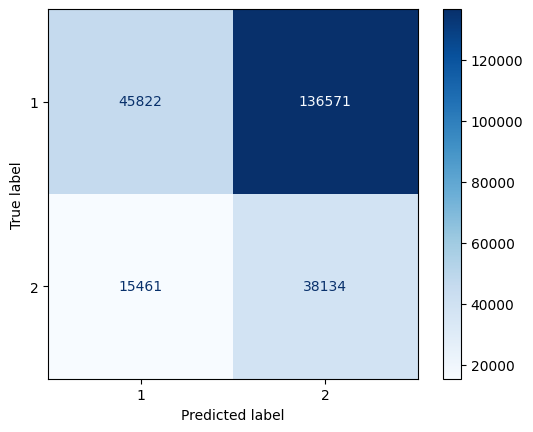

model weights: [[-7.83404017e-23 -1.50536637e-27  1.22147925e-34]]
model bias: [-2.45726898e-34]
Running experiment: cubic_rank_dt_zc_1000
Data: cubic_rank_dt_zc_1000, a
Train: (943949, 1000)
Test (rank): (235988, 1000)
              precision    recall  f1-score   support

           1     0.8300    0.8099    0.8198    182393
           2     0.4023    0.4355    0.4183     53595

    accuracy                         0.7248    235988
   macro avg     0.6162    0.6227    0.6190    235988
weighted avg     0.7329    0.7248    0.7286    235988

Confusion matrix


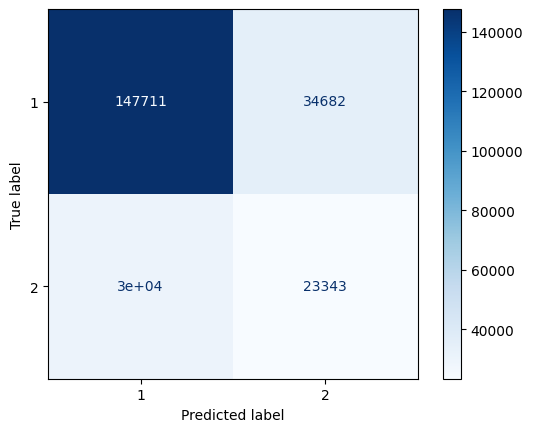

Running experiment: cubic_rank_lr_zc_1000
Data: cubic_rank_lr_zc_1000, a
Train: (943949, 1000)
Test (rank): (235988, 1000)


/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           1     0.7742    0.9972    0.8716    182393
           2     0.5143    0.0101    0.0198     53595

    accuracy                         0.7730    235988
   macro avg     0.6442    0.5036    0.4457    235988
weighted avg     0.7151    0.7730    0.6782    235988

Confusion matrix


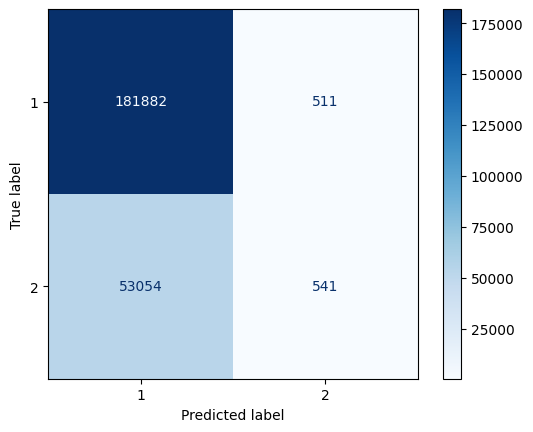

In [10]:
run_experiments(
    df_cubic,
    "cubic_rank",
    class_names=["1", "2"],
    current_dir=current_dir,
    save_tree_fig=False,
)

Predict only using $c_0$ and $c_1$, which yields a similar accuracy and learns decision boundary corresponds to the discriminant.

              precision    recall  f1-score   support

           1     0.9912    0.9921    0.9916    182393
           2     0.9730    0.9700    0.9715     53595

    accuracy                         0.9871    235988
   macro avg     0.9821    0.9811    0.9816    235988
weighted avg     0.9871    0.9871    0.9871    235988



/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/inspection/_plot/decision_boundary.py:194: UserWarning: The following kwargs were not used by contour: 'feature_names'
  self.surface_ = plot_func(self.xx0, self.xx1, self.response, **kwargs)


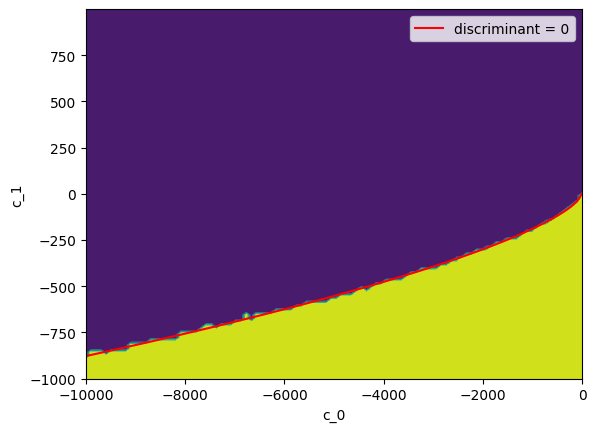

/Users/seewoolee/Documents/development/ml-nf/.venv/lib/python3.13/site-packages/sklearn/inspection/_plot/decision_boundary.py:194: UserWarning: The following kwargs were not used by contour: 'feature_names'
  self.surface_ = plot_func(self.xx0, self.xx1, self.response, **kwargs)


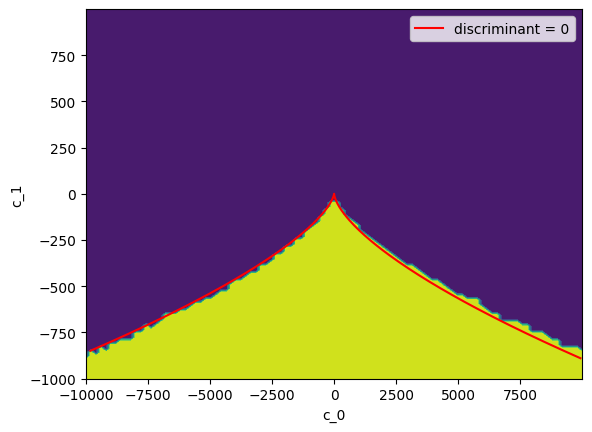

In [11]:
X, y = X_y(df_cubic, degree=3, feature_type="c", label="rank")
X_c01 = X.select(["c_0", "c_1"])

X_train, X_test, y_train, y_test = train_test_split(X_c01, y, test_size=0.2, random_state=42)

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred = model_dt.predict(X_test)
clr = classification_report(y_test, y_pred, digits=4)
print(clr)

X_c2_0 = X.filter(pl.col("c_2") == 0).select(["c_0", "c_1"])
X_c2_0 = X_c2_0.filter(pl.col("c_0") >= -10000, pl.col("c_0") <= 0, pl.col("c_1") >= -1000, pl.col("c_1") <= 1000)

X_c2_m1 = X.filter(pl.col("c_2") == -1).select(["c_0", "c_1"])
X_c2_m1 = X_c2_m1.filter(pl.col("c_0") >= -10000, pl.col("c_0") <= 10000, pl.col("c_1") >= -1000, pl.col("c_1") <= 1000)

# discriminant of x^3 + c_1 * x + c_0 is -4 * c_1^3 - 27 * c_0^2
disp_0 = DecisionBoundaryDisplay.from_estimator(model_dt, X_c2_0, feature_names=["c_0", "c_1"])
c2_0_c0s = np.linspace(-10000, 0, 100)
c2_0_c1s = -(27 / 4) ** (1/3) * (c2_0_c0s ** 2) ** (1/3)
plt.plot(c2_0_c0s, c2_0_c1s, color="red", label="discriminant = 0")
plt.legend()
plt.savefig(f"{current_dir}/figs/dt/cubic_rank_c01_c2_0_dt.png")
plt.show()

# discriminant of x^3 - x^2 + c_1 * x + c_0 is c_1^2 - 4 * c_1^3 + 4 * c_0 - 27 * c_0^2 - 18 * c_0 * c_1
disp_m1 = DecisionBoundaryDisplay.from_estimator(model_dt, X_c2_m1, feature_names=["c_0", "c_1"])
c2_m1_c1s_1 = np.linspace(-850, -1/3, 100)
c2_m1_c1s_2 = np.linspace(-1/3, -890, 100)
c2_m1_c0s_1 = ((9 * c2_m1_c1s_1 - 2) - 2 * (-27 * (c2_m1_c1s_1 ** 3 - c2_m1_c1s_1 ** 2) - 18 * c2_m1_c1s_1 + 4) ** (1/2)) / 27
c2_m1_c0s_2 = ((9 * c2_m1_c1s_2 - 2) + 2 * (-27 * (c2_m1_c1s_2 ** 3 - c2_m1_c1s_2 ** 2) - 18 * c2_m1_c1s_2 + 4) ** (1/2)) / 27
c2_m1_c0s = np.concatenate((c2_m1_c0s_1, c2_m1_c0s_2))
c2_m1_c1s = np.concatenate((c2_m1_c1s_1, c2_m1_c1s_2))
plt.plot(c2_m1_c0s, c2_m1_c1s, color="red", label="discriminant = 0")
plt.legend()
plt.savefig(f"{current_dir}/figs/dt/cubic_rank_c01_c2_m1_dt.png")
plt.show()